In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

raw = yf.download("SPY", start='2025-01-01', end='2026-01-01')
data = raw.droplevel("Ticker", axis=1)
data['daily_return'] = data['Close'].pct_change()
data['rolling_vol'] = data['daily_return'].rolling(21).std() * np.sqrt(252)

[*********************100%***********************]  1 of 1 completed


In [3]:
#Define threshold: use the median rolling vol as our cutoff
vol_threshold = data['rolling_vol'].median()
print(f"Volatility threshold: {vol_threshold:.2%}")

#Create signal: 1 = stay invested, 0 = move to cash
data['signal'] = np.where(data['rolling_vol'] < vol_threshold, 1, 0)

#Strategy return: only earn SPY's return when signal = 1
data['strategy_return'] = data['signal'] * data['daily_return']

print(data[['daily_return', 'rolling_vol', 'signal', 'strategy_return']].head(30))

Volatility threshold: 12.80%
Price       daily_return  rolling_vol  signal  strategy_return
2025-01-02           NaN          NaN       0              NaN
2025-01-03      0.012503          NaN       0         0.000000
2025-01-06      0.005761          NaN       0         0.000000
2025-01-07     -0.011304          NaN       0        -0.000000
2025-01-08      0.001461          NaN       0         0.000000
2025-01-10     -0.015268          NaN       0        -0.000000
2025-01-13      0.001551          NaN       0         0.000000
2025-01-14      0.001376          NaN       0         0.000000
2025-01-15      0.018190          NaN       0         0.000000
2025-01-16     -0.001923          NaN       0        -0.000000
2025-01-17      0.010040          NaN       0         0.000000
2025-01-21      0.009153          NaN       0         0.000000
2025-01-22      0.005622          NaN       0         0.000000
2025-01-23      0.005458          NaN       0         0.000000
2025-01-24     -0.002919  

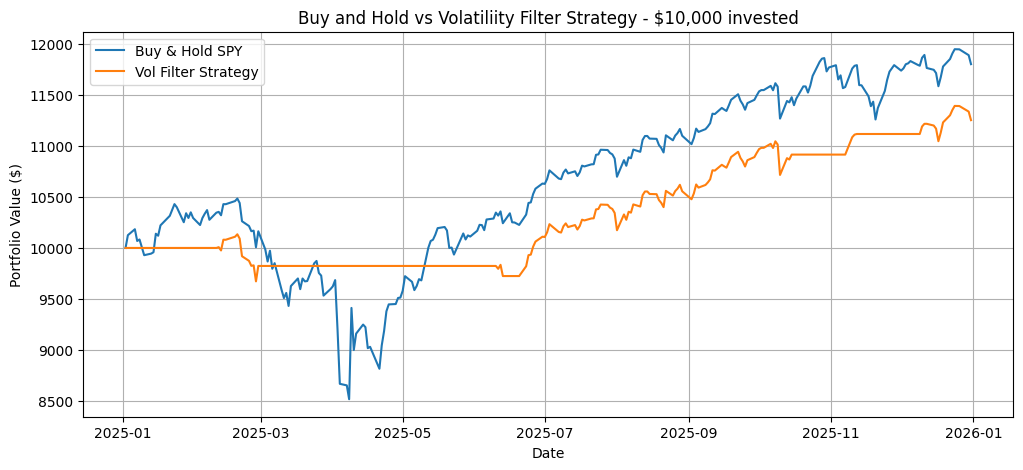

In [4]:
#fillna(0) -> Replace NaN to (0)
data['cumulative_strategy'] = (1 + data['strategy_return'].fillna(0)).cumprod()
data['cumulative_buyhold'] = (1 + data['daily_return'].fillna(0)).cumprod()

plt.figure(figsize=(12,5))
plt.plot(data['cumulative_buyhold'] * 10000, label='Buy & Hold SPY')
plt.plot(data['cumulative_strategy'] * 10000, label='Vol Filter Strategy')
plt.title("Buy and Hold vs Volatiliity Filter Strategy - $10,000 invested")
plt.ylabel("Portfolio Value ($)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
final_buyhold = data['cumulative_buyhold'].iloc[-1]
final_strategy = data['cumulative_strategy'].iloc[-1]

print(f"Buy & Hold final: ${final_buyhold*10000:.2f}")
print(f"Strategy final: ${final_strategy*10000:.2f}")

strategy_sharpe = (data['strategy_return'].mean() / data['strategy_return'].std()) * np.sqrt(252)
buyhold_sharpe = (data['daily_return'].mean() / data['daily_return'].std()) * np.sqrt(252)

print(f"Buy & Hold Sharpe: {buyhold_sharpe:.4f}")
print(f"Strategy Sharpe: {strategy_sharpe:.4f}")

Buy & Hold final: $11800.90
Strategy final: $11252.17
Buy & Hold Sharpe: 0.9548
Strategy Sharpe: 1.6793
